In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

train_df = pd.read_csv("../data/splits/train.csv")

train_df.head()

ModuleNotFoundError: No module named 'matplotlib'

In [2]:
!pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 599.9 kB/s eta 0:00:15
   -- ------------------------------------- 0.5/9.3 MB 599.9 kB/s eta 0:00:15
   --- ------------------------------------ 0.8/9.3 MB 568.6 kB/s eta 0:00:16
   --- ------------------------------------ 0.8/9.3 MB 568.6 kB/s eta 0:00:16
   --- ------------------------------------ 0.8/9.3 MB 568.6 kB/s eta 0:00:16
   ---- ----------------------------------- 1.0/9.3 MB 474.9 kB/s eta 0:00:18
   ---- ----------------------------------- 1.0/9.3 MB 474.9 kB/s eta 0:00:18
   ---- -----------------------


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd

train_df = pd.read_csv("../data/splits/train.csv")

train_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_late
0,4cebb64502b3c7295709a972ae314c7c,bc20aa7ab38261667b10117ac0b169c5,delivered,2017-08-26 11:35:05,2017-08-26 11:50:14,2017-08-30 18:13:57,2017-09-08 17:27:52,2017-09-18,0
1,161e8319860a634de1d366b52f246f8e,44716e9b2f5b438ee2b8631758563446,delivered,2018-06-12 12:08:29,2018-06-13 18:24:41,2018-06-14 14:01:00,2018-06-20 19:56:34,2018-07-05,0
2,3e5d9d4bd8c8fb94162c7aa9013240c9,2e9727b083f9dab08e56c61cd949c364,delivered,2018-08-10 17:09:53,2018-08-10 17:25:15,2018-08-15 13:35:00,2018-08-16 18:34:28,2018-08-27,0
3,29bd235b1e0eee8c72af9375033b5f8c,52e73a5d0a1d4c56b090cd70e0d678ee,delivered,2018-08-06 12:30:02,2018-08-06 12:44:20,2018-08-07 12:51:00,2018-08-27 13:06:43,2018-09-04,0
4,19ba784efbf17691a04ac155893e93b8,f53789fc4a603015c6e5a040fffb6cac,delivered,2018-08-07 13:03:24,2018-08-07 13:15:18,2018-08-08 14:43:00,2018-08-14 02:08:42,2018-08-13,1


In [2]:
print("Shape:", train_df.shape)

print("\nData types:")
print(train_df.dtypes)

print("\nMemory usage:")
train_df.info(memory_usage="deep")

Shape: (67534, 9)

Data types:
order_id                           str
customer_id                        str
order_status                       str
order_purchase_timestamp           str
order_approved_at                  str
order_delivered_carrier_date       str
order_delivered_customer_date      str
order_estimated_delivery_date      str
is_late                          int64
dtype: object

Memory usage:
<class 'pandas.DataFrame'>
RangeIndex: 67534 entries, 0 to 67533
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       67534 non-null  str  
 1   customer_id                    67534 non-null  str  
 2   order_status                   67534 non-null  str  
 3   order_purchase_timestamp       67534 non-null  str  
 4   order_approved_at              67522 non-null  str  
 5   order_delivered_carrier_date   67533 non-null  str  
 6   order_delivered_custome

In [3]:
train_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,67534,67534,4cebb64502b3c7295709a972ae314c7c,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,67534,67534,bc20aa7ab38261667b10117ac0b169c5,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,67534,1,delivered,67534,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,67534,67280,2017-11-20 10:59:08,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_approved_at,67522,63331,2018-02-27 04:31:10,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_delivered_carrier_date,67533,58368,2018-05-09 15:48:00,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_delivered_customer_date,67527,67113,2018-02-14 21:09:19,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_estimated_delivery_date,67534,441,2018-05-29,357,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_late,67534.0,NaN,NaN,NaN,0.081115,0.273013,0.0,0.0,0.0,0.0,1.0


In [4]:
missing = train_df.isnull().sum()

missing_df = pd.DataFrame(
    {"missing_count": missing, "missing_percentage": (missing / len(train_df)) * 100}
)

missing_df = missing_df[missing_df["missing_count"] > 0].sort_values(
    "missing_count", ascending=False
)

missing_df

,missing_count,missing_percentage
order_approved_at,12,0.017769
order_delivered_customer_date,7,0.010365
order_delivered_carrier_date,1,0.001481


In [5]:
train_df[train_df.isnull().any(axis=1)]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_late
7587,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaN,2018-06-26,0
7667,2eecb0d85f281280f79fa00f9cec1a95,a3d3c38e58b9d2dfb9207cab690b6310,delivered,2017-02-17 17:21:55,NaN,2017-02-22 11:42:51,2017-03-03 12:16:03,2017-03-20,0
9377,3c0b8706b065f9919d0505d3b3343881,d85919cb3c0529589c6fa617f5f43281,delivered,2017-02-17 15:53:27,NaN,2017-02-22 11:31:30,2017-03-03 11:47:47,2017-03-23,0
14512,7002a78c79c519ac54022d4f8a65e6e8,d5de688c321096d15508faae67a27051,delivered,2017-01-19 22:26:59,NaN,2017-01-27 11:08:05,2017-02-06 14:22:19,2017-03-16,0
15415,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23,0
20373,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24,0
20898,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30,0
23847,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16,0
30309,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,delivered,2017-02-19 01:28:47,NaN,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27,0
35598,88083e8f64d95b932164187484d90212,f67cd1a215aae2a1074638bbd35a223a,delivered,2017-02-18 22:49:19,NaN,2017-02-22 11:31:06,2017-03-02 12:06:06,2017-03-21,0


In [6]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in date_columns:
    train_df[col] = pd.to_datetime(train_df[col], errors="coerce")

train_df[date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [7]:
train_df["delivery_days"] = (
    train_df["order_delivered_customer_date"] - train_df["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

train_df["delivery_days"].describe()

count    67527.000000
mean        12.584216
std          9.597573
min          0.533414
25%          6.783461
50%         10.236991
75%         15.725394
max        209.628611
Name: delivery_days, dtype: float64

In [8]:
train_df.nlargest(10, "delivery_days")[
    [
        "order_id",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "delivery_days",
        "is_late",
    ]
]

,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,is_late
53746,ca07593549f1816d26a572e06dc1eab6,2017-02-21 23:31:27,2017-09-19 14:36:39,2017-03-22,209.628611,1
51562,440d0d17af552815d15a9e41abe49359,2017-03-07 23:59:51,2017-09-19 15:12:50,2017-04-07,195.634016,1
21113,2fb597c2f772eca01b1f5c561bf6cc7b,2017-03-08 18:09:02,2017-09-19 14:33:17,2017-04-17,194.850174,1
38400,0f4519c5f1c541ddec9f21b3bddd533a,2017-03-09 13:26:57,2017-09-19 14:38:21,2017-04-11,194.049583,1
1828,47b40429ed8cce3aee9199792275433f,2018-01-03 09:44:01,2018-07-13 20:51:31,2018-01-19,191.463542,1
18834,2fe324febf907e3ea3f2aa9650869fa5,2017-03-13 20:17:10,2017-09-19 17:00:07,2017-04-05,189.863160,1
38021,2d7561026d542c8dbd8f0daeadf67a43,2017-03-15 11:24:27,2017-09-19 14:38:18,2017-04-13,188.134618,1
57082,c27815f7e3dd0b926b58552628481575,2017-03-15 23:23:17,2017-09-19 17:14:25,2017-04-10,187.743843,1
57498,dfe5f68118c2576143240b8d78e5940a,2017-03-17 12:32:22,2017-09-19 18:13:19,2017-04-19,186.236771,1
57444,6e82dcfb5eada6283dba34f164e636f5,2017-05-17 19:09:02,2017-11-16 10:56:45,2017-06-14,182.658137,1


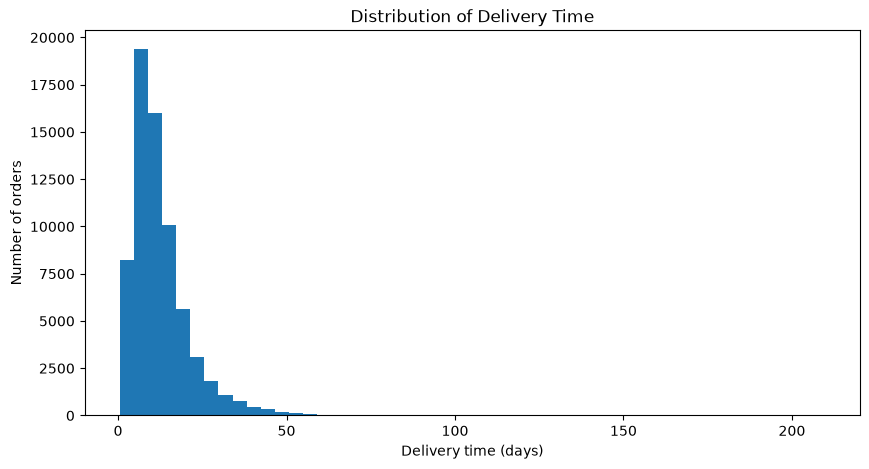

In [9]:
plt.figure(figsize=(10, 5))
plt.hist(train_df["delivery_days"].dropna(), bins=50)
plt.xlabel("Delivery time (days)")
plt.ylabel("Number of orders")
plt.title("Distribution of Delivery Time")
plt.show()

In [10]:
print("Skewness:", train_df["delivery_days"].skew())

print("\nQuantiles:")
print(train_df["delivery_days"].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]))

Skewness: 3.9495349817045677

Quantiles:
0.01     1.829343
0.05     3.031961
0.25     6.783461
0.50    10.236991
0.75    15.725394
0.95    29.364992
0.99    46.017462
Name: delivery_days, dtype: float64


In [11]:
train_df["delivery_delay_days"] = (
    train_df["order_delivered_customer_date"]
    - train_df["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 60 * 60)

print(train_df["delivery_delay_days"].describe())

print("\nLate label comparison:")
print(
    train_df.groupby("is_late")["delivery_delay_days"].agg(
        ["count", "mean", "median", "min", "max"]
    )
)

count    67527.000000
mean       -11.163207
std         10.215221
min       -146.016123
25%        -16.234294
50%        -11.926146
75%         -6.378617
max        181.608785
Name: delivery_delay_days, dtype: float64

Late label comparison:
         count       mean     median         min         max
is_late                                                     
0        62049 -12.993849 -12.313611 -146.016123   -0.000058
1         5478   9.572370   5.798108    0.002500  181.608785


In [12]:
train_df["purchase_day_of_week"] = train_df["order_purchase_timestamp"].dt.day_name()

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

day_late_rate = (
    train_df.groupby("purchase_day_of_week")["is_late"].mean().reindex(day_order) * 100
)

print(day_late_rate.round(2))

purchase_day_of_week
Monday       8.98
Tuesday      8.48
Wednesday    7.76
Thursday     7.60
Friday       8.70
Saturday     7.47
Sunday       7.42
Name: is_late, dtype: float64


In [13]:
train_df["purchase_month"] = train_df["order_purchase_timestamp"].dt.month

monthly_late_rate = train_df.groupby("purchase_month")["is_late"].mean().mul(100)

print(monthly_late_rate.round(2))

purchase_month
1      6.12
2     13.42
3     16.81
4      6.15
5      6.74
6      2.18
7      4.08
8      7.33
9      5.38
10     4.60
11    14.80
12     8.68
Name: is_late, dtype: float64


In [14]:
train_df["purchase_year"] = train_df["order_purchase_timestamp"].dt.year

year_month_late = (
    train_df.groupby(["purchase_year", "purchase_month"])["is_late"]
    .mean()
    .mul(100)
    .round(2)
)

print(year_month_late)

purchase_year  purchase_month
2016           10                 1.12
               12                 0.00
2017           1                  3.11
               2                  2.74
               3                  5.86
               4                  8.66
               5                  3.48
               6                  3.60
               7                  3.42
               8                  3.23
               9                  5.38
               10                 4.80
               11                14.80
               12                 8.68
2018           1                  6.46
               2                 16.13
               3                 20.86
               4                  5.29
               5                  8.43
               6                  1.45
               7                  4.50
               8                 10.09
Name: is_late, dtype: float64


In [15]:
print("Unique values:", train_df["order_status"].nunique())

print("\nValue counts:")
print(train_df["order_status"].value_counts(dropna=False))

Unique values: 1

Value counts:
order_status
delivered    67534
Name: count, dtype: int64


In [16]:
print("order_id unique:", train_df["order_id"].nunique())
print("customer_id unique:", train_df["customer_id"].nunique())

print("\nDuplicate order_ids:", train_df["order_id"].duplicated().sum())
print("Duplicate customer_ids:", train_df["customer_id"].duplicated().sum())

order_id unique: 67534
customer_id unique: 67534

Duplicate order_ids: 0
Duplicate customer_ids: 0


In [17]:
print(train_df.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'is_late', 'delivery_days', 'delivery_delay_days', 'purchase_day_of_week', 'purchase_month', 'purchase_year']


In [18]:
train_df["approval_delay_days"] = (
    train_df["order_approved_at"] - train_df["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

train_df["purchase_to_carrier_days"] = (
    train_df["order_delivered_carrier_date"] - train_df["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

train_df["carrier_to_customer_days"] = (
    train_df["order_delivered_customer_date"] - train_df["order_delivered_carrier_date"]
).dt.total_seconds() / (24 * 60 * 60)

train_df[
    ["approval_delay_days", "purchase_to_carrier_days", "carrier_to_customer_days"]
].describe()

,approval_delay_days,purchase_to_carrier_days,carrier_to_customer_days
count,67522.000000,67533.000000,67527.000000
mean,0.426746,3.232423,9.351746
std,0.853819,3.523818,8.811403
min,0.000000,-0.089468,-16.096169
25%,0.008958,1.130301,4.114057
50%,0.014248,2.208032,7.108137
75%,0.603038,4.070104,12.042413
max,30.893484,107.064606,195.033947


In [19]:
delay_cols = [
    "approval_delay_days",
    "purchase_to_carrier_days",
    "carrier_to_customer_days",
]

print(train_df.groupby("is_late")[delay_cols].mean().round(2))

         approval_delay_days  purchase_to_carrier_days  \
is_late                                                  
0                       0.42                      3.01   
1                       0.52                      5.75   

         carrier_to_customer_days  
is_late                            
0                            7.90  
1                           25.84  


In [20]:
numeric_cols = [
    "is_late",
    "delivery_days",
    "delivery_delay_days",
    "approval_delay_days",
    "purchase_to_carrier_days",
    "carrier_to_customer_days",
]

train_df[numeric_cols].corr()["is_late"].sort_values(ascending=False)

is_late                     1.000000
delivery_delay_days         0.603136
delivery_days               0.588380
carrier_to_customer_days    0.555895
purchase_to_carrier_days    0.212494
approval_delay_days         0.031288
Name: is_late, dtype: float64

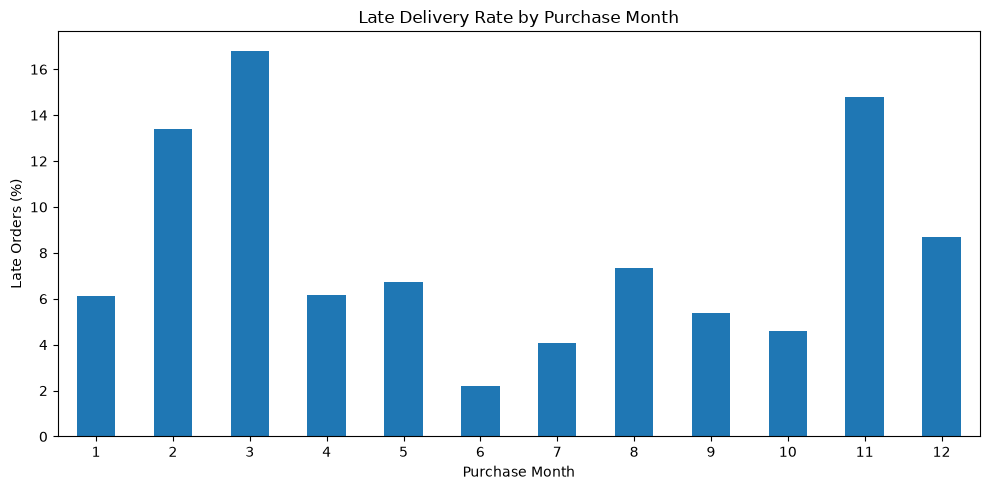

In [21]:
import matplotlib.pyplot as plt

os.makedirs("../artifacts/eda", exist_ok=True)

late_by_month = train_df.groupby("purchase_month")["is_late"].mean().mul(100)

plt.figure(figsize=(10, 5))
late_by_month.plot(kind="bar")
plt.xlabel("Purchase Month")
plt.ylabel("Late Orders (%)")
plt.title("Late Delivery Rate by Purchase Month")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../artifacts/eda/late_rate_by_month.png", dpi=150)
plt.show()

In [22]:
findings = """
# EDA Findings

- Training data contains 67,534 orders.
- order_status contains only "delivered", so it has no useful variation.
- order_id and customer_id are unique identifiers and should not be used directly as features.
- Missing values are very limited: 12 in order_approved_at, 1 in order_delivered_carrier_date, and 7 in order_delivered_customer_date.
- Delivery time is strongly right-skewed (skewness ≈ 3.95).
- Median delivery time is approximately 10.24 days.
- Some orders have extremely long delivery times, but these were retained because they may represent real observations.
- Late-delivery rates vary by purchase weekday and month.
- Monthly late rates vary across years, indicating time-related patterns.
- Variables based on actual delivery timestamps are useful for EDA but must not be used as predictive features because they are unavailable at prediction time and would cause data leakage.
- The current training split contains only order-level fields; customer/seller geography is not currently present in this split.
"""

with open("../artifacts/eda/findings_summary.md", "w", encoding="utf-8") as f:
    f.write(findings)

print("EDA artifacts saved successfully.")

EDA artifacts saved successfully.
